<a href="https://colab.research.google.com/github/sampabiet90/AIML/blob/LogicMojo-AI-ML-April26-sampa90/Netflix_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importing the required libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.shape

(8807, 12)

In [6]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


Is there any Duplicate Record in this dataset ? If yes, then remove the duplicate records.

In [8]:
df[df.duplicated()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


So . there is no duplicate in the dataset

 Is there any Null Value present in any column ? Show with Heat-map.

In [14]:
null_count = df.isnull().sum()
null_count
#null_count = null_count[null_count > 0]

#print(null_count.sort_values(ascending=False))

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


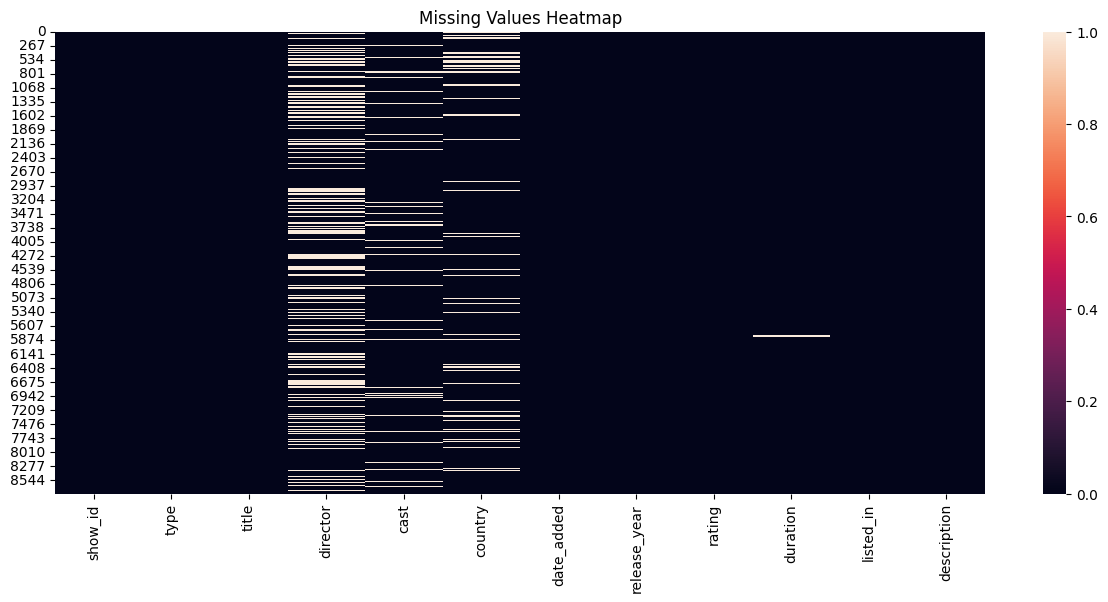

In [11]:
plt.figure(figsize=(15,6))
sns.heatmap(df.isnull())

plt.title('Missing Values Heatmap')
plt.show()

For 'House of Cards', what is the Show Id and Who is the Director of this show ?

In [20]:
df[df['title'] == 'House of Cards'][['show_id','director']]

,show_id,director
1059,s1060,NaN


In which year the highest number of the TV Shows & Movies were released ? Show with Bar Graph.

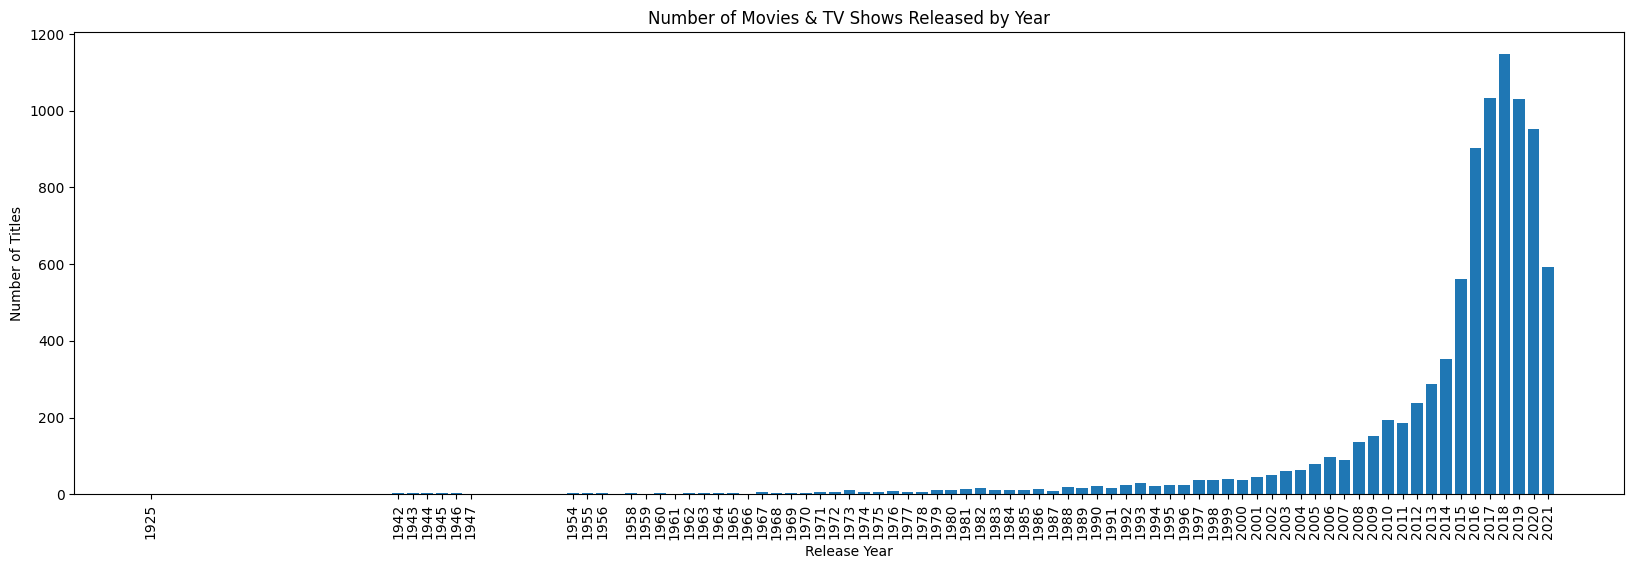

In [25]:
release_count = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(20,6))
plt.bar(release_count.index, release_count.values)

plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.title('Number of Movies & TV Shows Released by Year')
plt.xticks(release_count.index, rotation=90)
plt.show()

In [27]:
release_count = df['release_year'].value_counts().sort_index()
release_count.idxmax()

np.int64(2018)

How many Movies & TV Shows are in the dataset ? Show with Bar Graph.

In [29]:
df.shape

(8807, 12)

Show all the Movies that were released in year 2000.

In [31]:
df[df['release_year']==2000]['title']

,title
180,The Nutty Professor II: The Klumps
350,Space Cowboys
359,The Original Kings of Comedy
566,Charlie's Angels
593,Snow Day
779,Battlefield Earth
952,The Whole Nine Yards
2173,Moesha
3472,Rugrats in Paris: The Movie
4545,Monty Python: Before the Flying Circus


Show only the Titles of all TV Shows that were released in India only.

In [32]:
df[df['country']=='India']['title']

,title
4,Kota Factory
24,Jeans
39,Chhota Bheem
50,Dharmakshetra
66,Raja Rasoi Aur Anya Kahaniyan
...,...
8773,Yanda Kartavya Aahe
8775,Yeh Meri Family
8798,Zed Plus
8799,Zenda


Show Top 10 Directors, who gave the highest number of TV Shows & Movies to Netflix ?

In [34]:
df['director'].value_counts().nlargest(10)

,count
director,
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Martin Scorsese,12
Youssef Chahine,12
Jay Chapman,12


Show all the Records, where "Category is Movie and Type is Comedies" or "Country is United Kingdom".

In [42]:
df[( (df['type']=='Movie') & (df['listed_in'].str.contains('Comedies', na=False)) ) | (df['country']=='United Kingdom')]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
13,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",NaN,"September 22, 2021",2021,TV-PG,91 min,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...
22,s23,Movie,Avvai Shanmughi,K.S. Ravikumar,"Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...",NaN,"September 21, 2021",1996,TV-PG,161 min,"Comedies, International Movies",Newly divorced and denied visitation rights wi...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
...,...,...,...,...,...,...,...,...,...,...,...,...
8791,s8792,Movie,Young Adult,Jason Reitman,"Charlize Theron, Patton Oswalt, Patrick Wilson...",United States,"November 20, 2019",2011,R,94 min,"Comedies, Dramas, Independent Movies",When a divorced writer gets a letter from an o...
8793,s8794,Movie,"Yours, Mine and Ours",Raja Gosnell,"Dennis Quaid, Rene Russo, Sean Faris, Katija P...",United States,"November 20, 2019",2005,PG,88 min,"Children & Family Movies, Comedies",When a father of eight and a mother of 10 prep...
8798,s8799,Movie,Zed Plus,Chandra Prakash Dwivedi,"Adil Hussain, Mona Singh, K.K. Raina, Sanjay M...",India,"December 31, 2019",2014,TV-MA,131 min,"Comedies, Dramas, International Movies",A philandering small-town mechanic's political...
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...


In how many movies/shows, Tom Cruise was cast ?

In [44]:
df[df['cast'].str.contains('Tom Cruise', na=False)]['title'].count()

np.int64(2)

What are the different Ratings defined by Netflix ?

In [45]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR'], dtype=object)

 How many Movies got the 'TV-14' rating, in Canada ?

In [52]:
df[(df['type']=='Movie') & (df['rating']=='TV-14') & (df['country']=='Canada')].shape[0]

13

How many TV Shows got the 'R' rating, after year 2018 ?

In [54]:
df[(df['rating']=='R') & (df['release_year']>2018) & (df['type']=='TV Show')].shape[0]

0